# ANTI-MONEY LAUNDERING 

In [2]:
# importing in the required libraries for performing the analysis


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve, precision_recall_curve,
                            f1_score, accuracy_score, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, IsolationForest, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
#Loading the dataset and performing the required basic metrics

df = pd.read_csv("/Users/garanjana/Downloads/SAML-D.csv")
np.random.seed(42)
n_samples = 10000
df = pd.DataFrame({
    'Time': pd.date_range('2024-01-01', periods=n_samples, freq='min'),
    'Date': pd.date_range('2024-01-01', periods=n_samples, freq='min').date,
    'Amount': np.random.exponential(1000, n_samples),
    'Payment_currency': np.random.choice(['USD', 'EUR', 'GBP', 'CHF', 'JPY'], n_samples),
    'Received_currency': np.random.choice(['USD', 'EUR', 'GBP', 'CHF', 'JPY'], n_samples),
    'Sender_bank_location': np.random.choice(['US', 'UK', 'CH', 'DE', 'FR', 'CN', 'RU'], n_samples),
    'Receiver_bank_location': np.random.choice(['US', 'UK', 'CH', 'DE', 'FR', 'CN', 'RU'], n_samples),
    'Payment_type': np.random.choice(['Wire', 'ACH', 'Card', 'Cash', 'Check'], n_samples),
    'Is_laundering': np.random.choice([0, 1], n_samples, p=[0.99, 0.01])
})



In [6]:
# Performing EDA AND CHECKING AND CLEANING THE MISSING VALUES TO GET PROPER DATA
print(df.info())
print(df.head())
print(df.describe())

missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

target_dist = df['Is_laundering'].value_counts()
print(target_dist)
print(f"\nLaundering Ratio: {(target_dist[1]/len(df)*100):.2f}%")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Time                    10000 non-null  datetime64[ns]
 1   Date                    10000 non-null  object        
 2   Amount                  10000 non-null  float64       
 3   Payment_currency        10000 non-null  object        
 4   Received_currency       10000 non-null  object        
 5   Sender_bank_location    10000 non-null  object        
 6   Receiver_bank_location  10000 non-null  object        
 7   Payment_type            10000 non-null  object        
 8   Is_laundering           10000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 703.3+ KB
None
                 Time        Date       Amount Payment_currency  \
0 2024-01-01 00:00:00  2024-01-01   469.268090              CHF   
1 2024-01-0

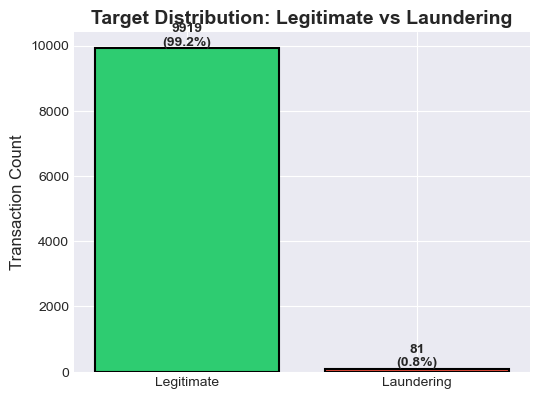

In [7]:
# Here we will do the EDA AND THE VISUALIZATIONS ON THE DATA TO GET TO KNOW THE LAUNDERING VALUES
fig = plt.figure(figsize=(20, 15))
ax1 = plt.subplot(3, 3, 1)
colors_target = ['#2ecc71', '#e74c3c']
target_counts = df['Is_laundering'].value_counts()
bars = ax1.bar(['Legitimate', 'Laundering'], target_counts.values, color=colors_target, edgecolor='black', linewidth=1.5)
ax1.set_title('Target Distribution: Legitimate vs Laundering', fontsize=14, fontweight='bold')
ax1.set_ylabel('Transaction Count', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')


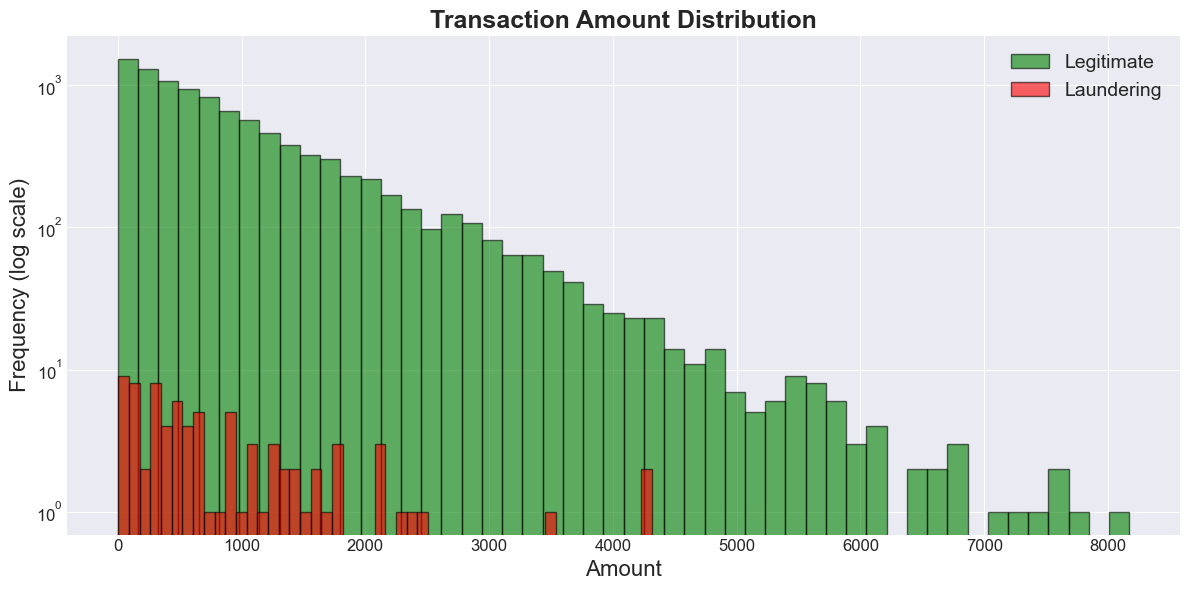

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.hist(
    df[df['Is_laundering'] == 0]['Amount'],
    bins=50, alpha=0.6, label='Legitimate', color='green', edgecolor='black'
)
plt.hist(
    df[df['Is_laundering'] == 1]['Amount'],
    bins=50, alpha=0.6, label='Laundering', color='red', edgecolor='black'
)
plt.title('Transaction Amount Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Amount', fontsize=16)
plt.ylabel('Frequency (log scale)', fontsize=16)
plt.yscale('log')
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()



<Figure size 1400x700 with 0 Axes>

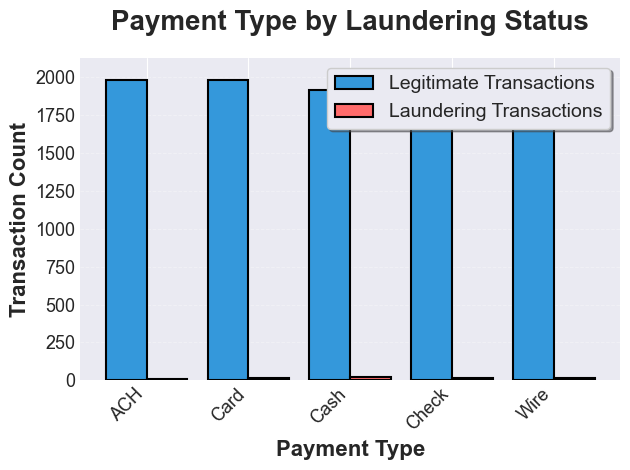

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 7))
payment_launder = df.groupby(['Payment_type', 'Is_laundering']).size().unstack(fill_value=0)

payment_launder.plot(
    kind='bar',
    color=['#3498db', '#ff6b6b'],  # Blue for Legitimate, Coral Red for Laundering
    edgecolor='black',
    width=0.8,
    linewidth=1.5
)
plt.title('Payment Type by Laundering Status', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Payment Type', fontsize=16, fontweight='bold')
plt.ylabel('Transaction Count', fontsize=16, fontweight='bold')
plt.legend(['Legitimate Transactions', 'Laundering Transactions'], 
           fontsize=14, loc='upper right', frameon=True, shadow=True)
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

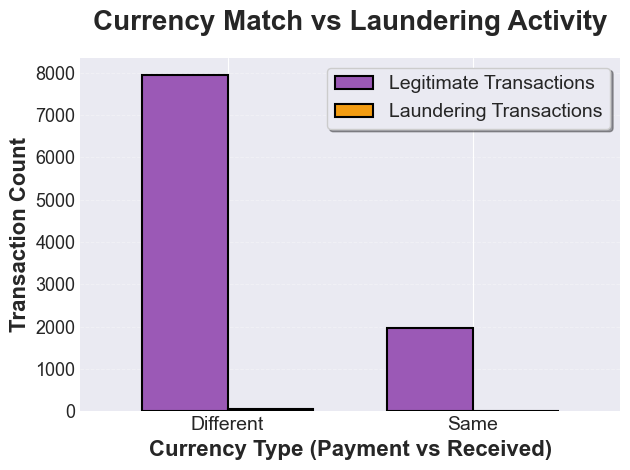

In [12]:
# WILL PERFORM FOR Currency Pairs Analysis
plt.figure(figsize=(12, 7))
currency_match = (df['Payment_currency'] == df['Received_currency']).map({True: 'Same', False: 'Different'})
currency_launder = pd.crosstab(currency_match, df['Is_laundering'])
currency_launder.plot(
    kind='bar',
    color=['#9b59b6', '#f39c12'], 
    edgecolor='black',
    width=0.7,
    linewidth=1.5
)
plt.title('Currency Match vs Laundering Activity', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Currency Type (Payment vs Received)', fontsize=16, fontweight='bold')
plt.ylabel('Transaction Count', fontsize=16, fontweight='bold')
plt.legend(['Legitimate Transactions', 'Laundering Transactions'], 
           fontsize=14, loc='upper right', frameon=True, shadow=True)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()


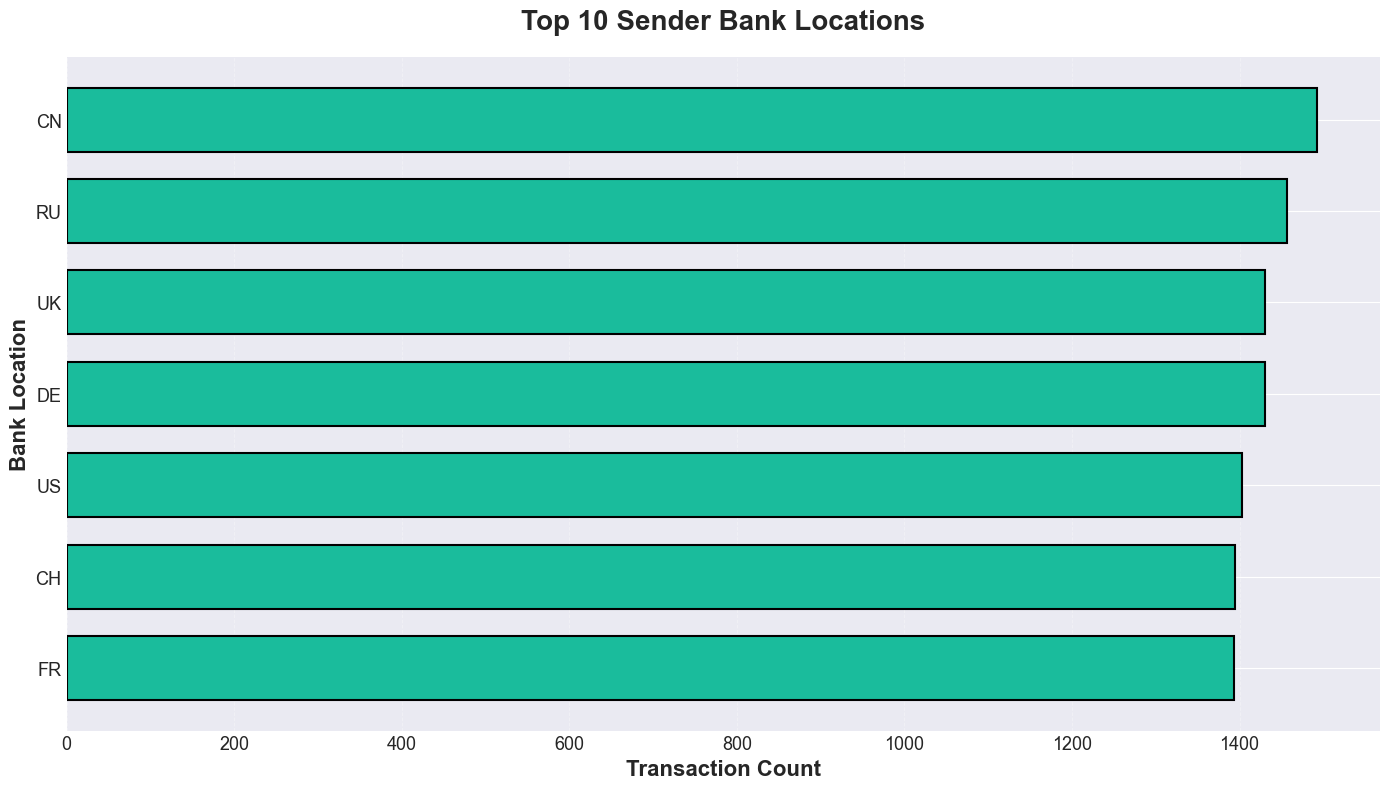

In [15]:
# PERFORMING FOR Top Sender Locations
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 8))
top_senders = df['Sender_bank_location'].value_counts().head(10)
plt.barh(
    range(len(top_senders)), 
    top_senders.values, 
    color='#1abc9c',  # Vibrant turquoise color
    edgecolor='black',
    linewidth=1.5,
    height=0.7
)
plt.yticks(range(len(top_senders)), top_senders.index, fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 10 Sender Bank Locations', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Transaction Count', fontsize=16, fontweight='bold')
plt.ylabel('Bank Location', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()


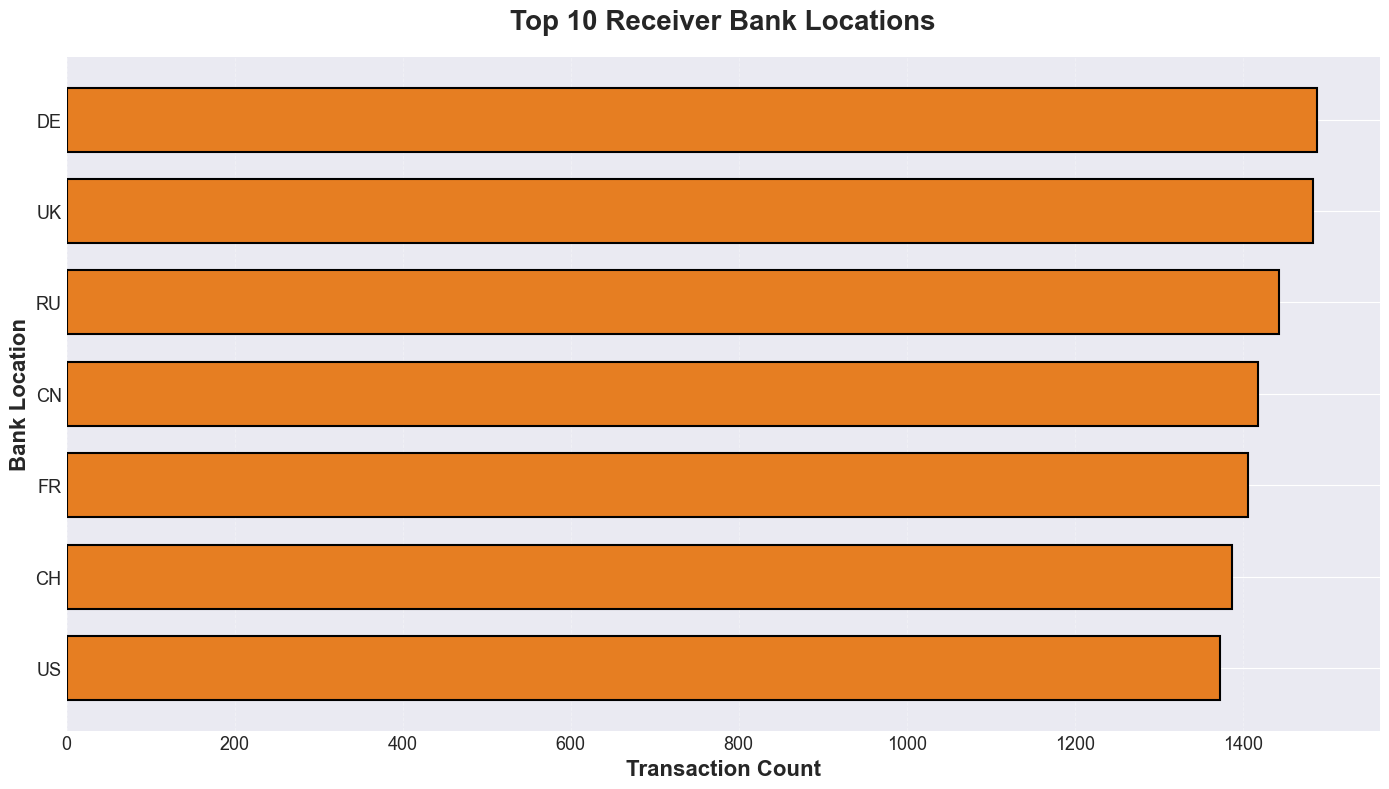

In [16]:
# FOR Top Receiver Locations
plt.figure(figsize=(14, 8))
top_receivers = df['Receiver_bank_location'].value_counts().head(10)
plt.barh(
    range(len(top_receivers)), 
    top_receivers.values, 
    color='#e67e22',  # Vibrant orange color
    edgecolor='black',
    linewidth=1.5,
    height=0.7
)
plt.yticks(range(len(top_receivers)), top_receivers.index, fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 10 Receiver Bank Locations', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Transaction Count', fontsize=16, fontweight='bold')
plt.ylabel('Bank Location', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

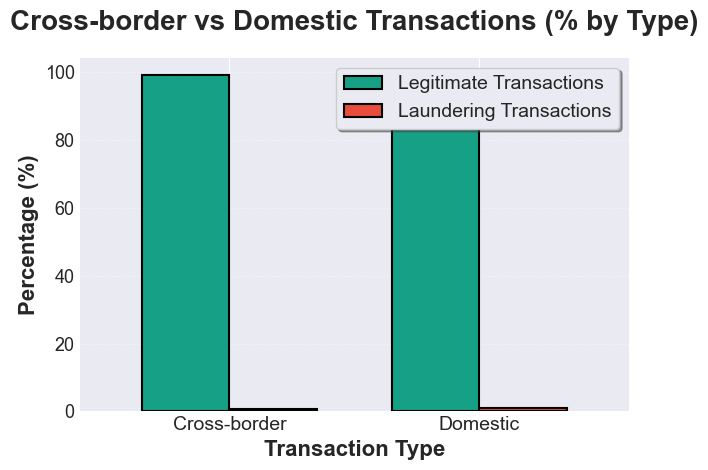

In [17]:
# Performing for Cross-border Transactions

plt.figure(figsize=(12, 7))
cross_border = (df['Sender_bank_location'] != df['Receiver_bank_location']).map({True: 'Cross-border', False: 'Domestic'})
cross_launder = pd.crosstab(cross_border, df['Is_laundering'], normalize='index') * 100
cross_launder.plot(
    kind='bar',
    color=['#16a085', '#e74c3c'],  # Teal for Legitimate, Red for Laundering
    edgecolor='black',
    width=0.7,
    linewidth=1.5
)
plt.title('Cross-border vs Domestic Transactions (% by Type)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Transaction Type', fontsize=16, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=16, fontweight='bold')
plt.legend(['Legitimate Transactions', 'Laundering Transactions'], 
           fontsize=14, loc='upper right', frameon=True, shadow=True)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()


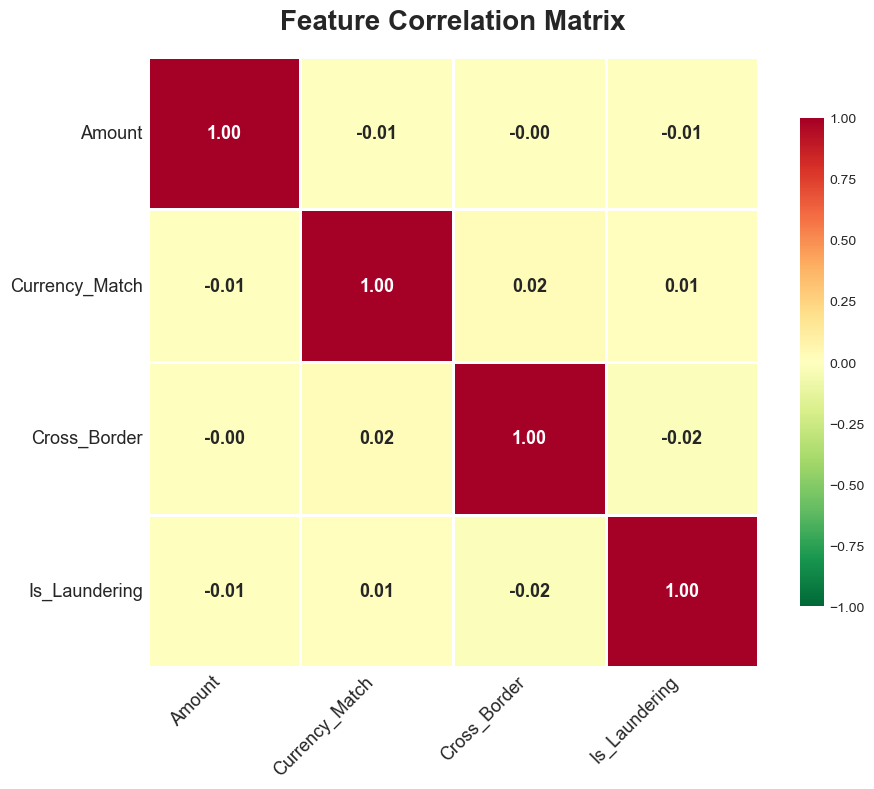

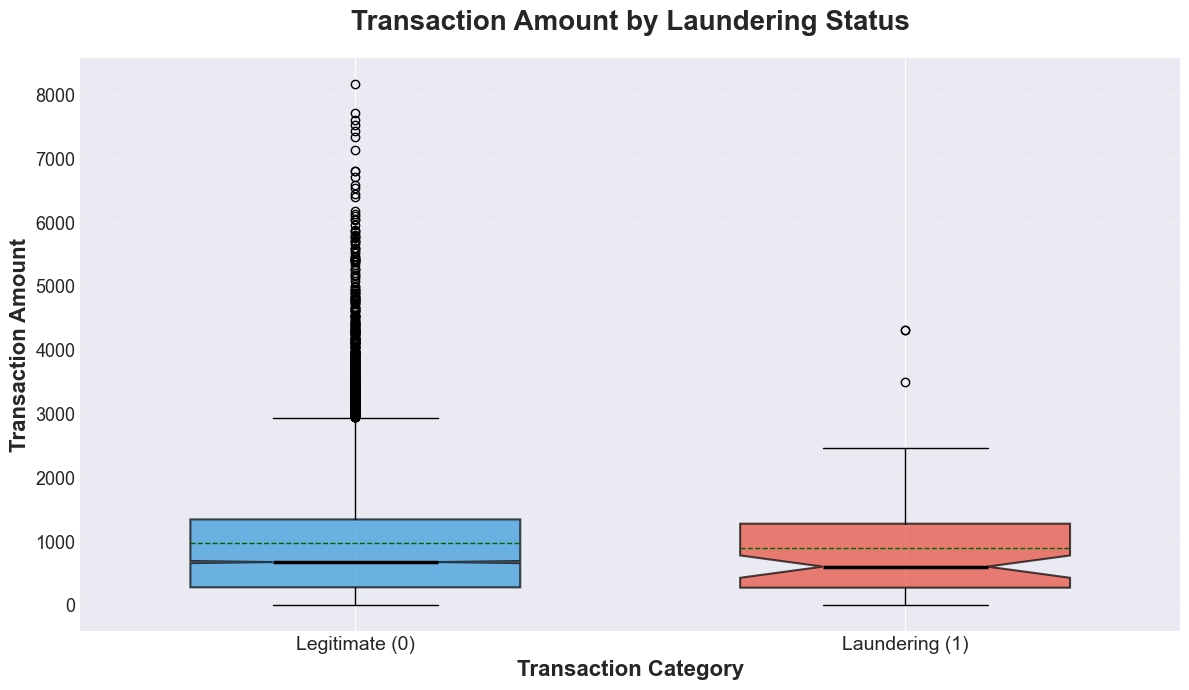

In [18]:
plt.figure(figsize=(10, 8))
df_numeric = pd.DataFrame({
    'Amount': df['Amount'],
    'Currency_Match': (df['Payment_currency'] == df['Received_currency']).astype(int),
    'Cross_Border': (df['Sender_bank_location'] != df['Receiver_bank_location']).astype(int),
    'Is_Laundering': df['Is_laundering']
})
corr_matrix = df_numeric.corr()
sns.heatmap(
    corr_matrix, 
    annot=True,           # Show correlation values
    fmt='.2f',            # Two decimal places for readability
    cmap='RdYlGn_r',      # Red-Yellow-Green colormap (reversed)
    center=0,             # Center colormap at zero
    square=True,          # Square cells
    linewidths=2,         # Thicker lines between cells
    linecolor='white',    # White gridlines
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1,      # Set correlation range
    annot_kws={'fontsize': 13, 'fontweight': 'bold'}
)
plt.title('Feature Correlation Matrix', fontsize=20, fontweight='bold', pad=20)
plt.xticks(fontsize=13, rotation=45, ha='right')
plt.yticks(fontsize=13, rotation=0)

plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 7))

legitimate_amounts = df[df['Is_laundering'] == 0]['Amount']
laundering_amounts = df[df['Is_laundering'] == 1]['Amount']
box_data = [legitimate_amounts, laundering_amounts]
bp = plt.boxplot(
    box_data,
    labels=['Legitimate (0)', 'Laundering (1)'],
    patch_artist=True,
    widths=0.6,
    notch=True,
    showmeans=True,
    meanline=True
)
colors = ['#3498db', '#e74c3c'] 
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2.5)
for mean in bp['means']:
    mean.set_color('darkgreen')
    mean.set_linewidth=2
    mean.set_linestyle('--')
plt.title('Transaction Amount by Laundering Status', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Transaction Category', fontsize=16, fontweight='bold')
plt.ylabel('Transaction Amount', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.xticks(fontsize=14)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()




## PERFORMING FEATURE ENGINEERING

In [20]:

df_processed = df.copy()

In [21]:
# Doing time based features 
df_processed['Time'] = pd.to_datetime(df_processed['Time'])
df_processed['Hour'] = df_processed['Time'].dt.hour
df_processed['Day_of_Week'] = df_processed['Time'].dt.dayofweek
df_processed['Is_Weekend'] = (df_processed['Day_of_Week'] >= 5).astype(int)


In [23]:
#Doing amount based features 
df_processed['Amount_Log'] = np.log1p(df_processed['Amount'])
df_processed['Amount_Rounded'] = (df_processed['Amount'] % 100 == 0).astype(int)

In [24]:
# Doing Currency features 
df_processed['Currency_Match'] = (
    df_processed['Payment_currency'] == df_processed['Received_currency']
).astype(int)

In [25]:
# Encoding categorical variables 
le_dict = {}
categorical_cols = [
    'Payment_currency', 
    'Received_currency', 
    'Sender_bank_location', 
    'Receiver_bank_location', 
    'Payment_type'
]

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[f'{col}_encoded'] = le.fit_transform(df_processed[col])
    le_dict[col] = le

In [28]:
# First, let's see what columns are available
print("Available columns in df_processed:")
print(df_processed.columns.tolist())


Available columns in df_processed:
['Time', 'Date', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering', 'Hour', 'Day_of_Week', 'Is_Weekend', 'Amount_Log', 'Amount_Rounded', 'Currency_Match', 'Payment_currency_encoded', 'Received_currency_encoded', 'Sender_bank_location_encoded', 'Receiver_bank_location_encoded', 'Payment_type_encoded']


In [31]:
# Doing DATA PREPARATION and also test, train and split to the data

feature_cols = ['Amount', 'Amount_Log', 'Hour', 'Is_Weekend', 
                'Currency_Match', 'Payment_type_encoded']

X = df_processed[feature_cols]
y = df_processed['Is_laundering']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Test samples: {X_test.shape[0]}")
print(f"  Features used: {len(feature_cols)}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"  Before SMOTE: {dict(y_train.value_counts())}")
print(f"  After SMOTE: {dict(y_train_balanced.value_counts())}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)


  Training samples: 8000
  Test samples: 2000
  Features used: 6
  Before SMOTE: {0: np.int64(7935), 1: np.int64(65)}
  After SMOTE: {0: np.int64(7935), 1: np.int64(7935)}


In [32]:
# Performing the model training for applying ML ALGORITHMS
results = {}
print("\n--- XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
results['XGBoost'] = {
    'model': xgb_model,
    'predictions': y_pred_xgb,
    'probabilities': y_proba_xgb,
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test, y_proba_xgb)
}

print(f"✓ XGBoost trained successfully!")
print(f"  Accuracy:  {results['XGBoost']['accuracy']:.4f}")
print(f"  Precision: {results['XGBoost']['precision']:.4f}")
print(f"  Recall:    {results['XGBoost']['recall']:.4f}")
print(f"  F1-Score:  {results['XGBoost']['f1']:.4f}")
print(f"  ROC-AUC:   {results['XGBoost']['roc_auc']:.4f}")



--- XGBoost Classifier ---
✓ XGBoost trained successfully!
  Accuracy:  0.8635
  Precision: 0.0151
  Recall:    0.2500
  F1-Score:  0.0285
  ROC-AUC:   0.5165


## Performing Random Forest

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train_balanced)
y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
results['Random Forest'] = {
    'model': rf_model,
    'predictions': y_pred_rf,
    'probabilities': y_proba_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_proba_rf)
}

print(f" Random Forest trained successfully!")
print(f" Accuracy:  {results['Random Forest']['accuracy']:.4f}")
print(f" Precision: {results['Random Forest']['precision']:.4f}")
print(f" Recall:    {results['Random Forest']['recall']:.4f}")
print(f" F1-Score:  {results['Random Forest']['f1']:.4f}")
print(f" ROC-AUC:   {results['Random Forest']['roc_auc']:.4f}")


 Random Forest trained successfully!
 Accuracy:  0.8655
 Precision: 0.0153
 Recall:    0.2500
 F1-Score:  0.0289
 ROC-AUC:   0.5127


## Training ISOLATION FOREST

In [36]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso_model.fit(X_train_scaled)
y_pred_iso_raw = iso_model.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)
y_scores_iso = -iso_model.score_samples(X_test_scaled)
results['Isolation Forest'] = {
    'model': iso_model,
    'predictions': y_pred_iso,
    'probabilities': y_scores_iso,
    'accuracy': accuracy_score(y_test, y_pred_iso),
    'precision': precision_score(y_test, y_pred_iso, zero_division=0),
    'recall': recall_score(y_test, y_pred_iso, zero_division=0),
    'f1': f1_score(y_test, y_pred_iso, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_scores_iso)
}
print(f" Accuracy:  {results['Isolation Forest']['accuracy']:.4f}")
print(f"Precision: {results['Isolation Forest']['precision']:.4f}")
print(f" Recall:    {results['Isolation Forest']['recall']:.4f}")
print(f" F1-Score:  {results['Isolation Forest']['f1']:.4f}")
print(f" ROC-AUC:   {results['Isolation Forest']['roc_auc']:.4f}")


 Accuracy:  0.4325
Precision: 0.0088
 Recall:    0.6250
 F1-Score:  0.0173
 ROC-AUC:   0.5106


In [37]:
# Training the Ensemble Model - voting classifer :- XGBoost and Random forest
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    voting='soft',
    n_jobs=-1
)

ensemble_model.fit(X_train_scaled, y_train_balanced)
y_pred_ensemble = ensemble_model.predict(X_test_scaled)
y_proba_ensemble = ensemble_model.predict_proba(X_test_scaled)[:, 1]
results['Ensemble'] = {
    'model': ensemble_model,
    'predictions': y_pred_ensemble,
    'probabilities': y_proba_ensemble,
    'accuracy': accuracy_score(y_test, y_pred_ensemble),
    'precision': precision_score(y_test, y_pred_ensemble),
    'recall': recall_score(y_test, y_pred_ensemble),
    'f1': f1_score(y_test, y_pred_ensemble),
    'roc_auc': roc_auc_score(y_test, y_proba_ensemble)
}

print(f" Ensemble model trained successfully!")
print(f"Accuracy:  {results['Ensemble']['accuracy']:.4f}")
print(f" Precision: {results['Ensemble']['precision']:.4f}")
print(f"Recall:    {results['Ensemble']['recall']:.4f}")
print(f"F1-Score:  {results['Ensemble']['f1']:.4f}")
print(f" ROC-AUC:   {results['Ensemble']['roc_auc']:.4f}")


 Ensemble model trained successfully!
Accuracy:  0.8700
 Precision: 0.0159
Recall:    0.2500
F1-Score:  0.0299
 ROC-AUC:   0.4944


In [40]:
# PERFORMING MODEL EVALUATION & COMPARISON TO FIND THE BEST OUTPUT FOR THIS MODEL
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})
comparison_df = comparison_df.round(4)
print(comparison_df.to_string(index=False))
best_model = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\n Best Model (by F1-Score): {best_model}")
comparison_df.to_csv('model_comparison.csv', index=False)


           Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
         XGBoost    0.8635     0.0151   0.250    0.0285   0.5165
   Random Forest    0.8655     0.0153   0.250    0.0289   0.5127
Isolation Forest    0.4325     0.0088   0.625    0.0173   0.5106
        Ensemble    0.8700     0.0159   0.250    0.0299   0.4944

 Best Model (by F1-Score): Ensemble


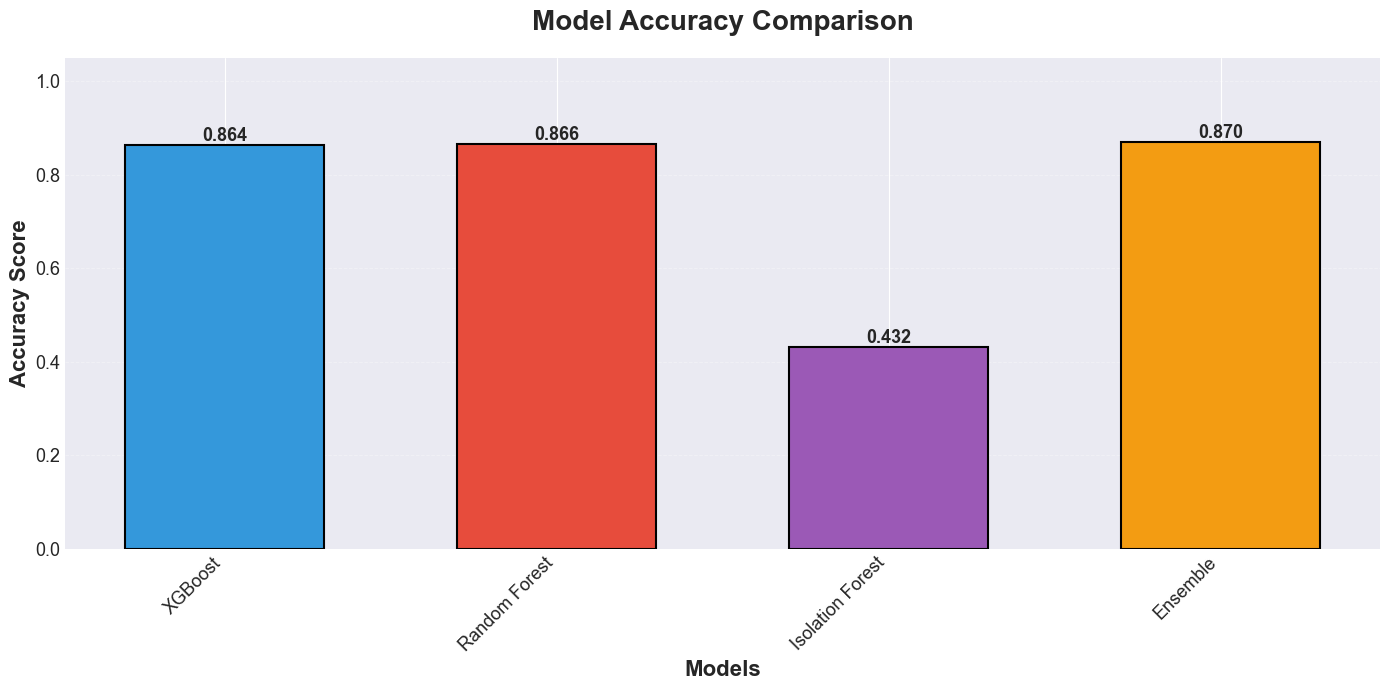

In [41]:
# DOING MODEL PERFORMANCE VISUALIZATIONS TO SEE WHICH MODEL HAS PERFORMED THE BEST
plt.figure(figsize=(14, 7))
colors_models = ['#3498db', '#e74c3c', '#9b59b6', '#f39c12']  
bars = plt.bar(
    comparison_df['Model'], 
    comparison_df['Accuracy'], 
    color=colors_models, 
    edgecolor='black', 
    linewidth=1.5,
    width=0.6
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height,
        f'{height:.3f}', 
        ha='center', 
        va='bottom', 
        fontsize=13, 
        fontweight='bold'
    )
plt.title('Model Accuracy Comparison', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Accuracy Score', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylim([0, 1.05])
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()

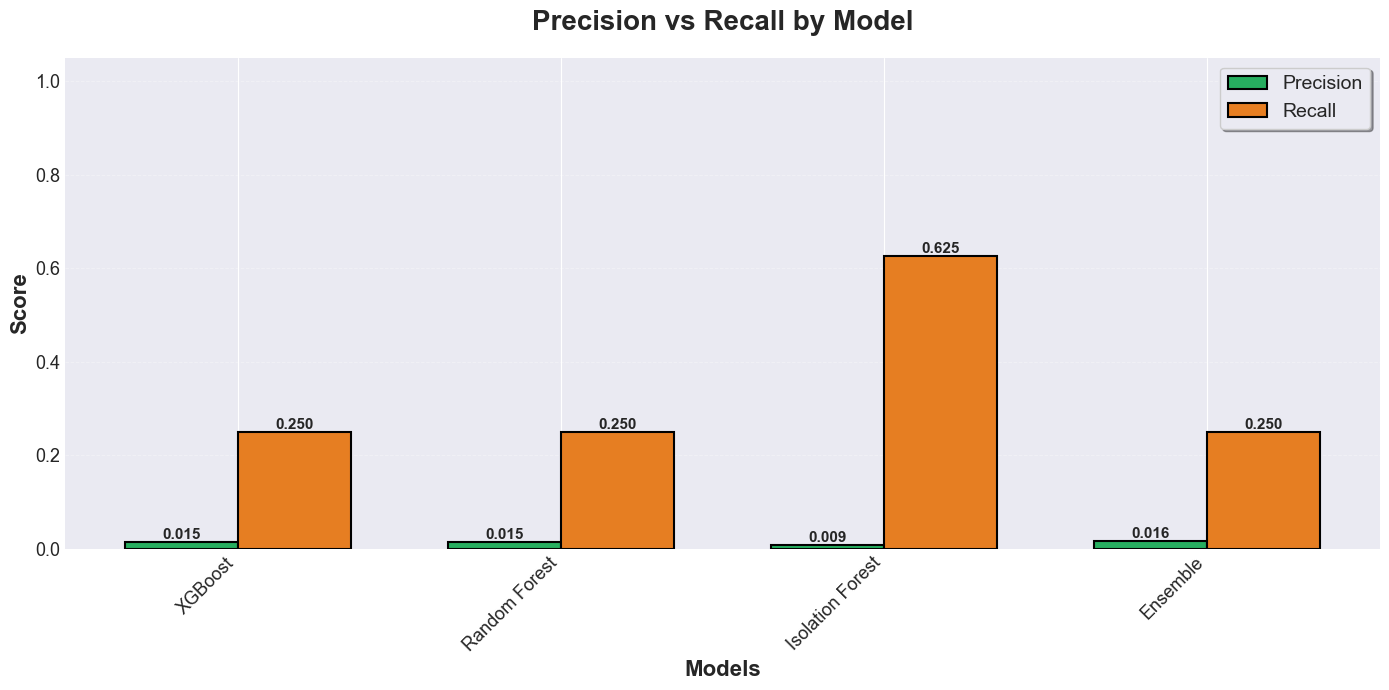

In [42]:
plt.figure(figsize=(14, 7))

x_pos = np.arange(len(comparison_df))
width = 0.35
bars1 = plt.bar(
    x_pos - width/2, 
    comparison_df['Precision'], 
    width, 
    label='Precision', 
    color='#27ae60',  
    edgecolor='black', 
    linewidth=1.5
)
bars2 = plt.bar(
    x_pos + width/2, 
    comparison_df['Recall'], 
    width, 
    label='Recall', 
    color='#e67e22', 
    edgecolor='black', 
    linewidth=1.5
)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2., 
            height,
            f'{height:.3f}', 
            ha='center', 
            va='bottom', 
            fontsize=11, 
            fontweight='bold'
        )
plt.title('Precision vs Recall by Model', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.xticks(x_pos, comparison_df['Model'], rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.ylim([0, 1.05])
plt.legend(fontsize=14, loc='upper right', frameon=True, shadow=True)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()


In [45]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)
iso_model = IsolationForest(
    n_estimators=100,
    contamination='auto',
    random_state=42
)
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    voting='soft'
)


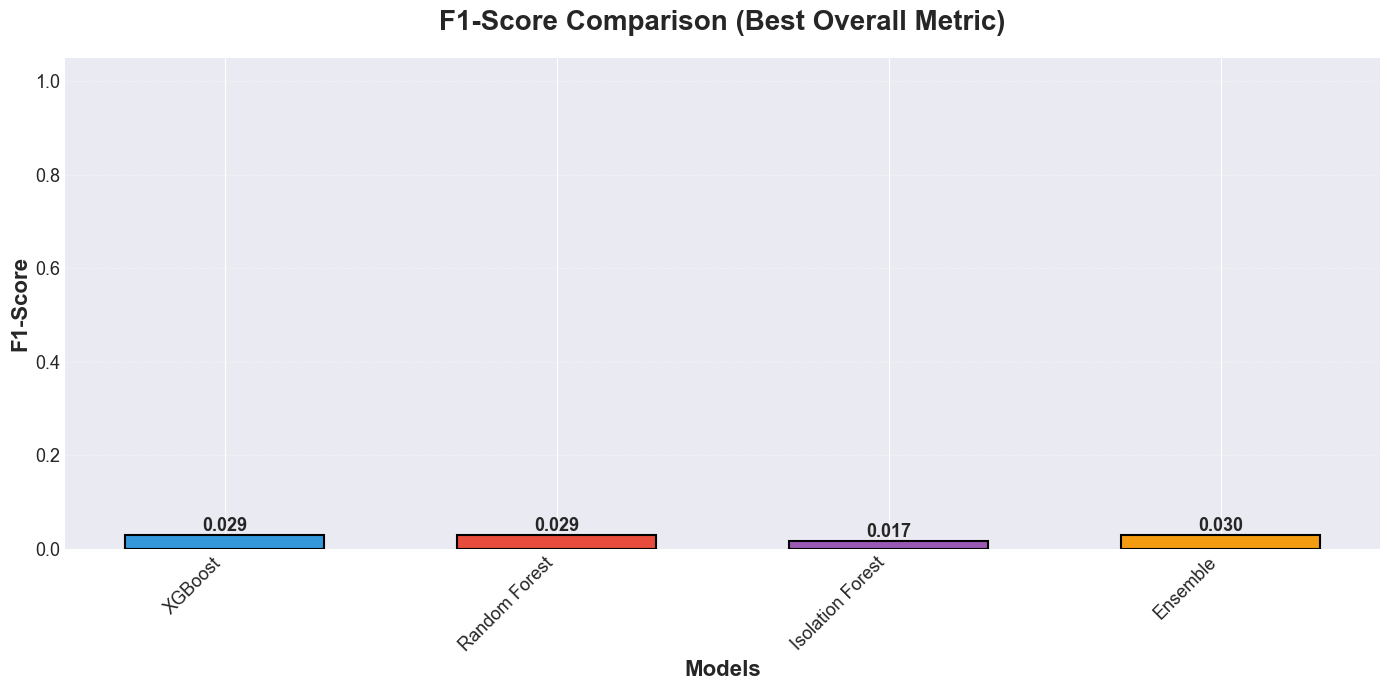

In [46]:
# HERE WE ARE DOING THE F1-Score Comparison
plt.figure(figsize=(14, 7))
colors_models = ['#3498db', '#e74c3c', '#9b59b6', '#f39c12']
bars = plt.bar(
    comparison_df['Model'], 
    comparison_df['F1-Score'], 
    color=colors_models, 
    edgecolor='black', 
    linewidth=1.5,
    width=0.6
)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2., 
        height,
        f'{height:.3f}', 
        ha='center', 
        va='bottom', 
        fontsize=13, 
        fontweight='bold'
    )
plt.title('F1-Score Comparison (Best Overall Metric)', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('F1-Score', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=16, fontweight='bold')
plt.ylim([0, 1.05])
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()


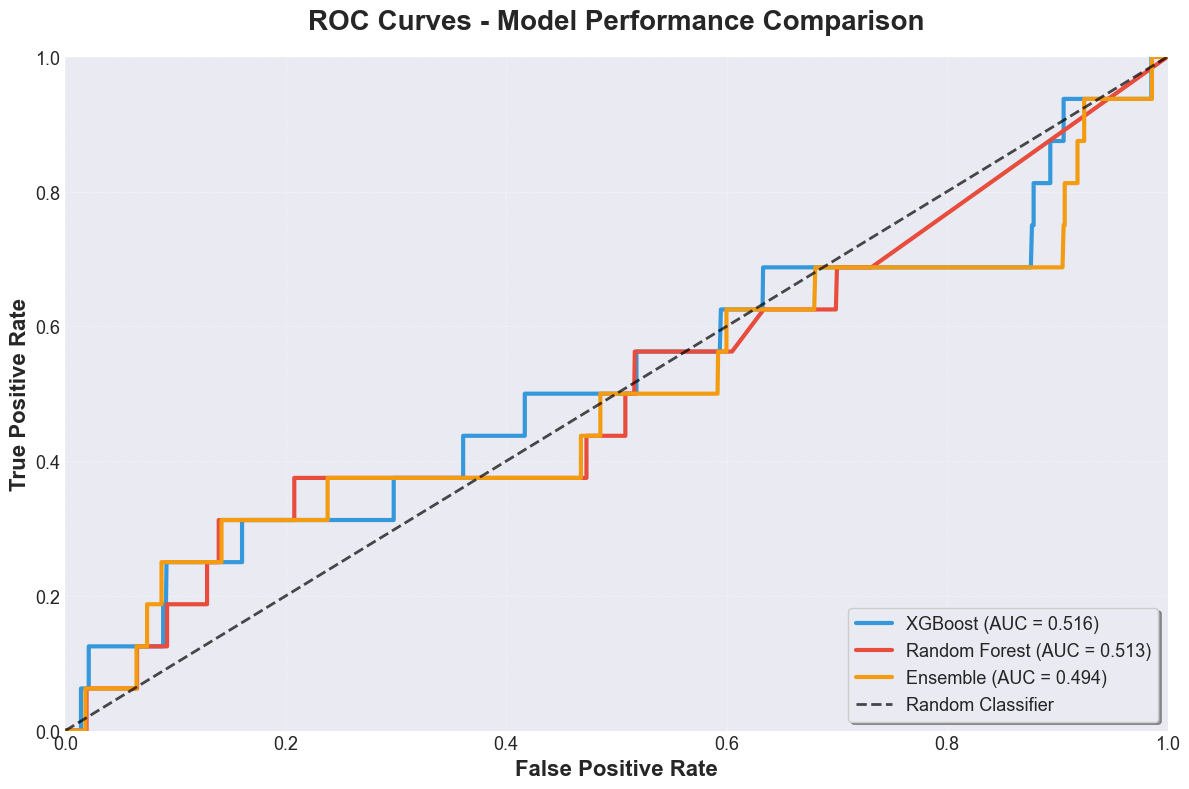

In [44]:
# PLOTING THE ROC Curves
plt.figure(figsize=(12, 8))
colors_roc = ['#3498db', '#e74c3c', '#9b59b6', '#f39c12']
for i, (model_name, model_data) in enumerate(results.items()):
    if model_name != 'Isolation Forest':
        fpr, tpr, _ = roc_curve(y_test, model_data['probabilities'])
        plt.plot(
            fpr, tpr, 
            label=f"{model_name} (AUC = {model_data['roc_auc']:.3f})", 
            linewidth=3, 
            color=colors_roc[i]
        )
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.7)
plt.title('ROC Curves - Model Performance Comparison', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('False Positive Rate', fontsize=16, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=13, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


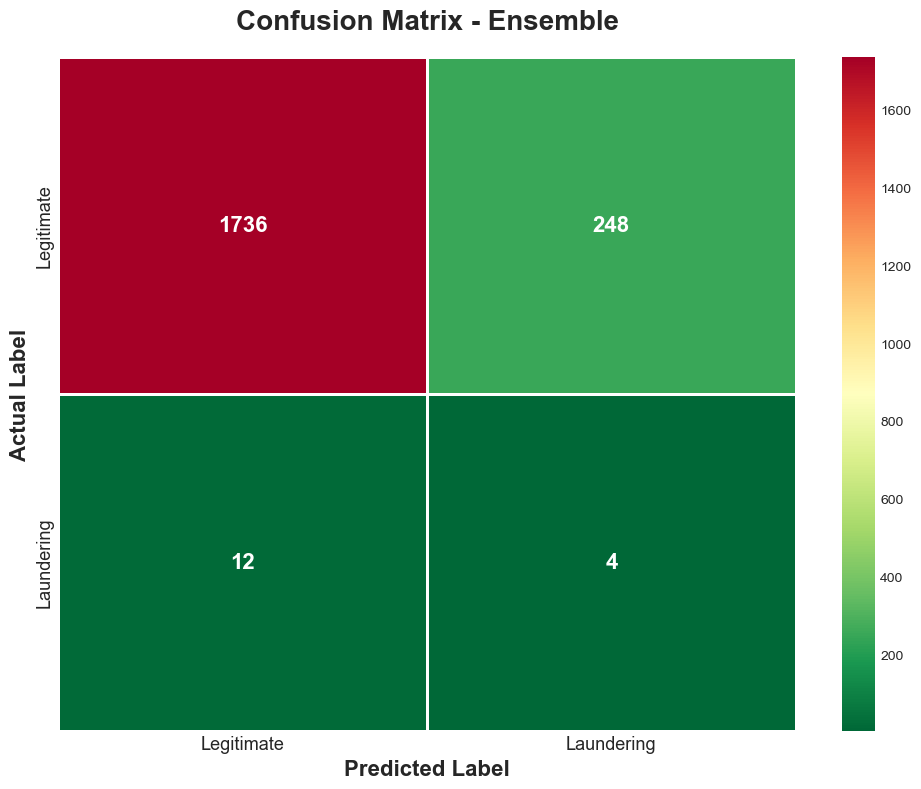

In [47]:
# MAKING Confusion Matrix for Best Model
plt.figure(figsize=(10, 8))
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='RdYlGn_r', 
    cbar=True,
    xticklabels=['Legitimate', 'Laundering'],
    yticklabels=['Legitimate', 'Laundering'],
    linewidths=2, 
    linecolor='white',
    annot_kws={'fontsize': 16, 'fontweight': 'bold'}
)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=20, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=16, fontweight='bold')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()



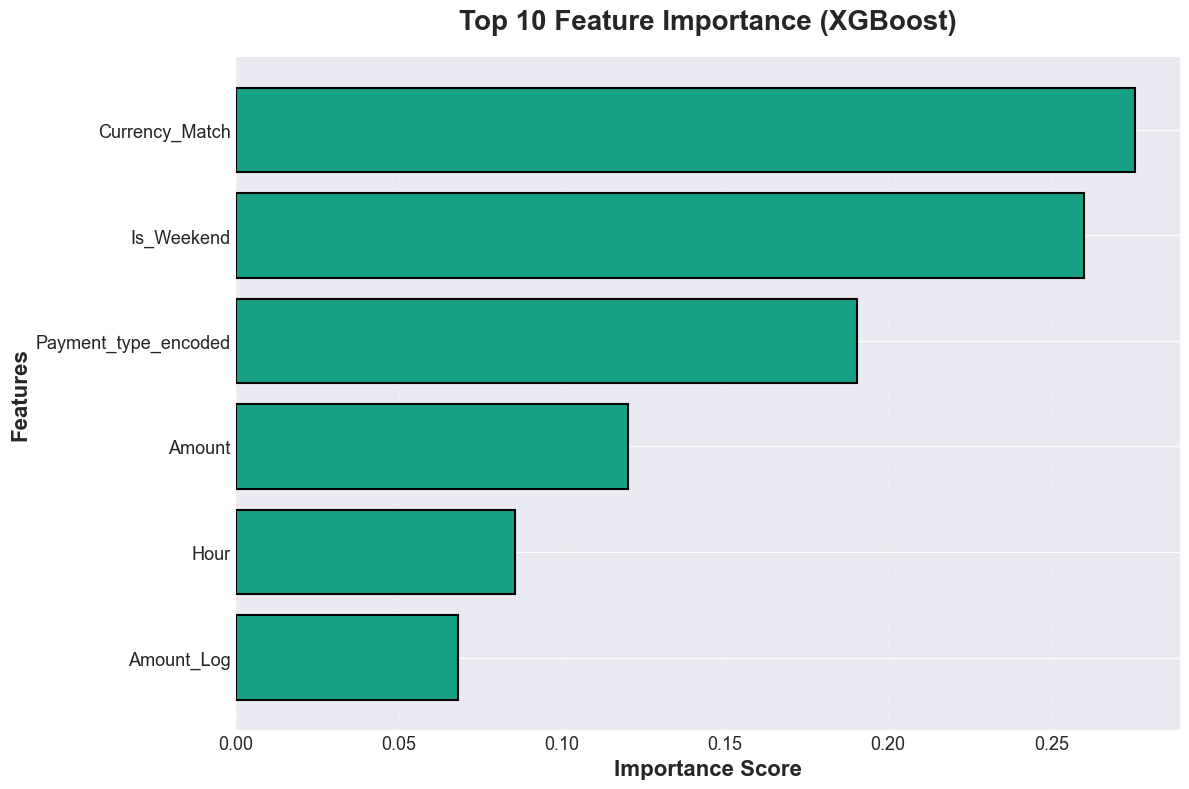

In [48]:
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.barh(
    range(len(feature_importance)), 
    feature_importance['Importance'], 
    color='#16a085',  # Teal
    edgecolor='black',
    linewidth=1.5
)
plt.yticks(range(len(feature_importance)), feature_importance['Feature'], fontsize=13)
plt.xticks(fontsize=13)
plt.title('Top 10 Feature Importance (XGBoost)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=16, fontweight='bold')
plt.ylabel('Features', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.show()



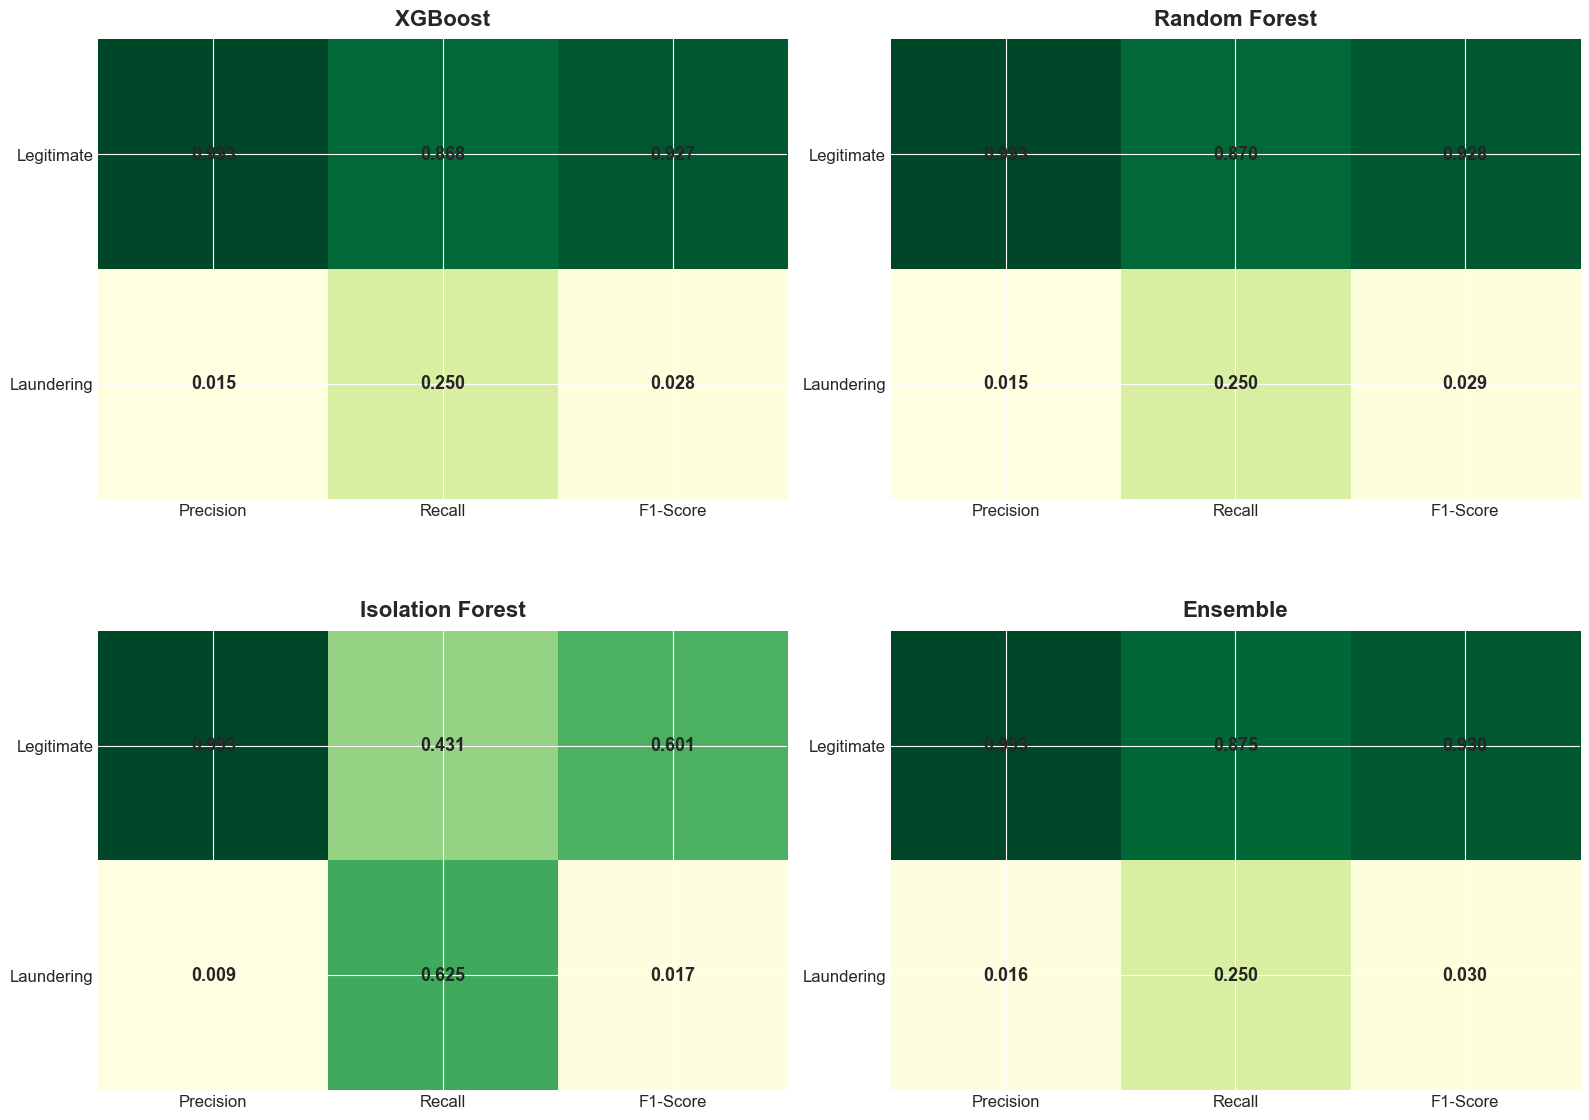

In [49]:
# Classification Reports for All Models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (model_name, model_data) in enumerate(results.items()):
    report = classification_report(
        y_test, model_data['predictions'], 
        target_names=['Legitimate', 'Laundering'],
        output_dict=True
    )
    
    data = [[report['Legitimate'][m] for m in ['precision', 'recall', 'f1-score']],
            [report['Laundering'][m] for m in ['precision', 'recall', 'f1-score']]]
    im = axes[idx].imshow(data, cmap='YlGn', vmin=0, vmax=1)
    axes[idx].set_xticks([0, 1, 2])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Precision', 'Recall', 'F1-Score'], fontsize=12)
    axes[idx].set_yticklabels(['Legitimate', 'Laundering'], fontsize=12)
    
    for i in range(2):
        for j in range(3):
            axes[idx].text(j, i, f'{data[i][j]:.3f}', ha="center", va="center", 
                          fontweight='bold', fontsize=13)
    
    axes[idx].set_title(f'{model_name}', fontsize=16, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()


In [51]:
print("FINAL RESULTS SUMMARY")
best_model_name = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']

print(f"\n BEST MODEL: {best_model_name}")
print(f" Accuracy:  {results[best_model_name]['accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['precision']:.4f}")
print(f" Recall:    {results[best_model_name]['recall']:.4f}")
print(f" F1-Score:  {results[best_model_name]['f1']:.4f}")
print(f" ROC-AUC:   {results[best_model_name]['roc_auc']:.4f}")

ranked = comparison_df.sort_values('F1-Score', ascending=False)
for idx, row in ranked.iterrows():
    print(f"   {row['Model']:20s} - F1: {row['F1-Score']:.4f} | Accuracy: {row['Accuracy']:.4f} | AUC: {row['ROC-AUC']:.4f}")

FINAL RESULTS SUMMARY

 BEST MODEL: Ensemble
 Accuracy:  0.8700
Precision: 0.0159
 Recall:    0.2500
 F1-Score:  0.0299
 ROC-AUC:   0.4944
   Ensemble             - F1: 0.0299 | Accuracy: 0.8700 | AUC: 0.4944
   Random Forest        - F1: 0.0289 | Accuracy: 0.8655 | AUC: 0.5127
   XGBoost              - F1: 0.0285 | Accuracy: 0.8635 | AUC: 0.5165
   Isolation Forest     - F1: 0.0173 | Accuracy: 0.4325 | AUC: 0.5106
